# Практическая работа 1. Классификация

**Работу выполнил (а):**

Карпова Алиса Станиславовна




## Текст задания

### Распознавание активности человека на основе данных с мобильных сенсоров

Необходимо по данным с мобильных сенсоров при помощи прикладных алгоритмов машинного обучения предсказать активность человека по шести классам движений:
* Движется по прямой
* Движется вверх (например, движение по лестнице вверх)
* Движется вниз (например, движение по лестнице вниз)
* Сидит
* Стоит
* Лежит

### Сведения о наборе данных
Набор данных содержит записи датчиков со сматфонов (акселерометр и гироскоп с частотой дискретизации 50 Гц) от 30 участников, выполняющих следующие действия: ходьба, ходьба по лестнице, ходьба по лестнице, сидение, стояние и лежание. Данные были предварительно обработаны при помощи фильтров шума. Набор данных представлен Хорхе Л. Рейес-Ортисом.

Признаки были извлечены из 3-х осевых необработанных сигналов акселерометра и гироскопа tAcc-XYZ и tGyro-XYZ. Эти сигналы были сняты с постоянной частотой 50 Гц. Затем были отфильтрованны с помощью медианного фильтра и низкочастотного фильтра Баттерворта 3-го порядка с частотой 20 Гц для удаления шумов. Аналогичным образом сигнал ускорения был разделен на сигналы ускорения тела и гравитации (`tBodyAcc-XYZ` и `tGravityAcc-XYZ`) с помощью другого низкочастотного фильтра Баттерворта с угловой частотой 0,3 Гц. Линейное ускорение тела и угловая скорость были использованы для получения сигналов "рывка" — (`tBodyAccJerk-XYZ` и `tBodyGyroJerk-XYZ`). Также величина этих трехмерных сигналов была расчитана с использованием евклидовой нормы — (`tBodyAccMag`, `tGravityAccMag`, `tBodyAccJerkMag`, `tBodyGyroMag`, `tBodyGyroJerkMag`).

Наконец, к некоторым из этих сигналов было применено быстрое преобразование Фурье (БПФ), в результате чего получились `fBodyAcc-XYZ`, `fBodyAccJerk-XYZ`, `fBodyGyro-XYZ`, `fBodyAccJerkMag`, `fBodyGyroMag`, `fBodyGyroJerkMag`. (Обратите внимание на "f" для обозначения сигналов в частотной области).

Набор переменных, которые были оценены по этим сигналам, следующий:
* mean(): Среднее значение
* std(): Стандартное отклонение
* mad(): Среднее абсолютное отклонение
* max(): Наибольшее значение в массиве
* min(): Наименьшее значение в массиве
* sma(): Область величины сигнала
* energy(): Мера энергии. Сумма квадратов, деленная на количество значений.
* iqr(): Интерквартильный размах
* entropy(): Энтропия сигнала
* arCoeff(): Коэффициенты авторегрессии с порядком Burg, равным 4
* correlation(): коэффициент корреляции между двумя сигналами
* maxInds(): индекс частотной составляющей с наибольшей величиной
* meanFreq(): средневзвешенное значение частотных компонент для получения средней частоты
* skewness(): перекос сигнала в частотной области
* kurtosis(): эксцесс сигнала в частотной области
* bandsEnergy(): Энергия частотного интервала в пределах 64 бинов БПФ каждого окна.
* angle(): Угол между векторами.





## Ход выполнения задания

### Импорт библиотек
Первым делом импортируем необходимые библиотеки для работы с данными:

In [ ]:
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt

### Загрузка наборов данных

В рамках данной работы опускается процесс feature engineering, используются предобработанные данные.

Загружаем полный набор данных и сохраним его под следующими четырьмя переменными:

* `train_X`: признаки, используемые для обучения модели
* `train_y`: метки, используемые для обучения модели
* `test_X`: признаки, используемые для проверки модели
* `test_y`: метки, используемые для проверки модели



In [ ]:
def read_data(path, filename):
    return pd.read_csv(os.path.join(path, filename))

df = read_data('C:/Users/Алиса/PycharmProjects/AI_lab1', 'train.csv')

label_dict = {'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':2, 'SITTING':3, 'STANDING':4, 'LAYING':5}

def load_dataset(label_dict):
    train_x = read_data('C:/Users/Алиса/PycharmProjects/AI_lab1', 'train.csv').values[:, :-2]
    train_y = read_data('C:/Users/Алиса/PycharmProjects/AI_lab1', 'train.csv')['Activity']
    train_y = train_y.map(label_dict).values

    test_x = read_data('C:/Users/Алиса/PycharmProjects/AI_lab1', 'test.csv').values[:, :-2]
    test_y = read_data('C:/Users/Алиса/PycharmProjects/AI_lab1', 'test.csv')['Activity']
    test_y = test_y.map(label_dict).values
    return(train_x, train_y, test_x, test_y)

train_x, train_y, test_x, test_y = load_dataset(label_dict)

### Выбор модели

В данной работе я попробовала использовать различные модели с различными гиперпараметрами. А именно, я решила использовать метод k ближайших соседей для классификации (kNN), а также метод опорных векторов (SVM), а именно его разновидности для multiclass classification: One vs One и One vs Rest.

Эффективность моделей была оценена по F1 (weighted) score.

Обсудим общие достоинства и недостатки выбранных моделей.

**k-Nearest Neighbors (k-NN):**

• Преимущества:
  * Простота: k-NN очень прост в понимании и реализации. Не требует сложного обучения; предсказания делаются на основе непосредственного вычисления расстояний до ближайших соседей.
  * Непараметрический: k-NN не предполагает никакой конкретной формы распределения данных. Это делает его достаточно гибким и устойчивым к выбросам.
  * Простота добавления новых данных: Новые данные легко интегрируются в модель k-NN без необходимости переобучения.

• Недостатки:
  * Высокая вычислительная сложность (особенно при Brute Force): Время предсказания может быть очень большим для больших наборов данных, так как необходимо вычислять расстояния до всех точек в обучающей выборке.
  * Чувствительность к масштабу признаков: Если признаки имеют разные масштабы, то признаки с большими значениями будут доминировать при вычислении расстояний. Необходимо проводить нормализацию или стандартизацию данных.
  * Выбор параметра k: Выбор оптимального значения k (количества ближайших соседей) важен и может потребовать экспериментального подбора.


**Support Vector Machines (SVM) - One-vs-Rest (OvR):**

• Преимущества:
  * Эффективность в высоких размерностях: SVM, особенно с ядром RBF, часто работает хорошо в пространствах высокой размерности, где k-NN может страдать от "проклятия размерности".
  * Строгая математическая основа: SVM имеет строгое математическое обоснование и часто дает хорошие результаты обобщения.
  * Устойчивость к выбросам: SVM меньше подвержен влиянию выбросов в данных.

• Недостатки:
  * Выбор параметров: Выбор оптимального ядра (kernel) и параметров ядра может потребовать тщательного подбора и валидации.
  * Время обучения: Время обучения может быть значительным для больших наборов данных.
  * Интерпретация: Интерпретация результатов SVM может быть сложнее, чем для k-NN.
  * Стратегия one vs rest позволяет обучать меньшее количество классификаторов, чем one vs one, но при большом количестве классов могут появляться проблемы, связанные с сильным дисбалансом классов при решении задачи “один против всех”. При большом количестве классов лучше использовать one vs one стратегию.


**Support Vector Machines (SVM) - One-vs-One (OvO):**

• Преимущества:
  * Эффективность в высоких размерностях: Как и OvR, хорошо работает в высоких размерностях.
  * Строгая математическая основа: Аналогично OvR.
  * Устойчивость к выбросам: Аналогично OvR.
  * Может быть точнее, чем OvR, особенно при сильном перекрытии классов, так как он сравнивает каждый класс напрямую с каждым другим классом.

• Недостатки:
  * Выбор параметров: Выбор параметров, аналогичный OvR.
  * Время обучения: Время обучения может быть еще больше, чем у OvR, так как обучается больше моделей.
  * Интерпретация: Интерпретация результатов сложнее, чем у k-NN.


Я выбрала данные модели для работы, поскольку, выбор этих трех моделей позволяет сравнить разные стратегии многоклассовой классификации. Более того, мы сможем наглядно увидеть разницу между работами параметрической и непараметрической моделей: k-NN — непараметрическая модель, SVM — параметрическая.

В целом, выбор моделей обусловлен их распространенностью, относительной простотой и различными сильными сторонами, которые могут быть полезны в ситуациях многоклассовой классификации. Наилучшая модель будет зависеть от специфики данных и оптимально подобранных гиперпараметров.










### Классификация методом kNN



В качестве изменяемых мной гиперпараметров я выбрала метрику расстояния (Евклидова, Манхэттенская и Чебышева), число соседей (от 1 до 30), а также алгоритм kNN (KD Tree, Brute Force). Я составила следующий план работы:



*   Для каждого из двух алгоритмов:
  *   Для каждой из трех метрик расстояния:
      * Выполнить классификацию, используя различные числа соседей k
      * Для каждой из комбинаций гиперпараметров рассчитать F1 score и Accuracy
      * Построить графики зависимостей F1 и Accuracy от числа соседей
      * Для модели, показавшей лучшие результаты согласно метрикам F1 и Accuracy, рассчитать precision и recall (classification report), построить confusion matrix.
*Применить GridSearch для поиска всех исслудемых оптимальных гиперпараметров. Рассчитать precision и recall (classification report), построить confusion matrix.

В первую очередь, необходимо нормализовать (масштабировать) данные:

In [ ]:
scaler = StandardScaler()
scaler.fit(train_x)
train_x_scaled = scaler.transform(train_x)
test_x_scaled = scaler.transform(test_x)

Обучим модель (объект класса KNeighborsClassification) с заданными гиперпараметрами metric = 'euclidian' и algorithm = 'brute', и попробуем подобрать оптимальное число соседей.

In [ ]:
num_neighbors = np.arange(1, 31)
quality_accuracy = np.zeros(num_neighbors.shape[0])
quality_F1 = np.zeros(num_neighbors.shape[0])
for i in range(num_neighbors.shape[0]):
    knn = KNeighborsClassifier(n_neighbors=num_neighbors[i], metric='euclidean', algorithm='brute')
    knn.fit(train_x_scaled, train_y)
    y_pred = knn.predict(test_x_scaled)
    accuracy = accuracy_score(y_pred, test_y)
    f1 = f1_score(y_pred, test_y, average = 'weighted')
    quality_accuracy[i] = accuracy
    quality_F1[i] = f1

max_F1, max_F1_neighbour = max(quality_F1), np.argmax(quality_F1) + 1
max_accuracy, max_accuracy_neighbour = max(quality_accuracy), np.argmax(quality_accuracy) + 1

Теперь построим графики зависимости F1 и Accuracy от k, и отметим на них точки с максимальными значениями метрик.

In [ ]:
plt.figure(figsize = (9, 6))
plt.suptitle("k-NN with euclidean metric and brute force algorithm", size = 18)

plt.subplot(2, 1, 1)
plt.title("Accuracy", size=16)
plt.xlabel("Neighbors", size=12)
plt.ylabel("Accuracy", size=12)
plt.xticks( np.arange(1, 31, 1))
plt.grid(True, which='both', linestyle = '--', linewidth = 0.5)
plt.plot(max_accuracy_neighbour, max_accuracy, marker='o', markersize=6, color = 'red')
plt.plot(num_neighbors, quality_accuracy)

plt.subplot(2, 1, 2)
plt.title("F1", size=16)
plt.xlabel("Neighbors", size=12)
plt.ylabel("F1", size=12)
plt.xticks( np.arange(1, 31, 1))
plt.grid(True, which='both', linestyle = '--', linewidth = 0.5)
plt.plot(max_F1_neighbour, max_F1, marker='o', markersize=6, color = 'red')
plt.plot(num_neighbors, quality_F1)
plt.tight_layout()
plt.show()

Результат построения графиков:
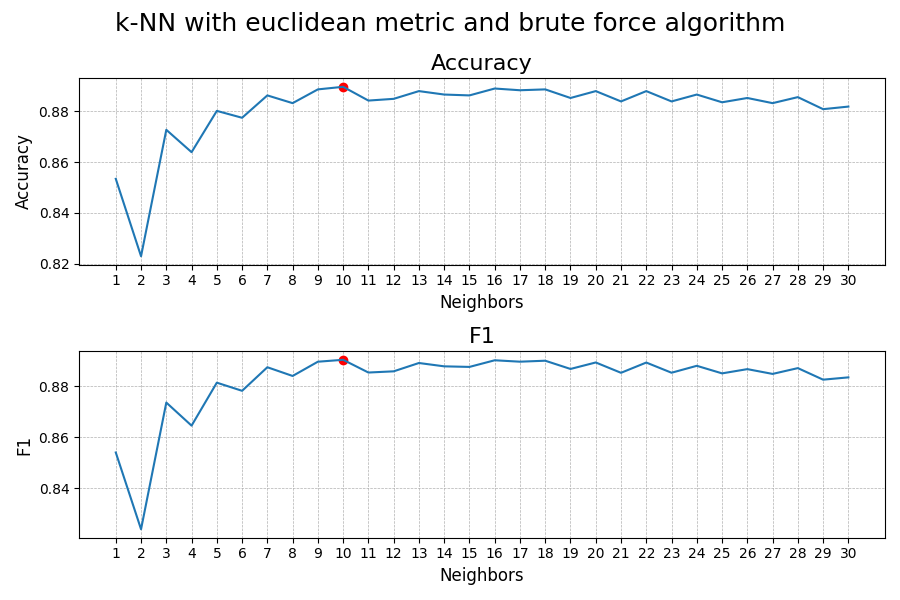



Мы можем видеть, что оценки по метрикам F1 и Асcuracy близки, и их значения максимальны при k = 10. Рассмотрим модель kNN с данными гиперпараметрами (k = 10, metric = euclidean, algorithm = brute) поближе:



In [ ]:
def quality_report(k, metric, algorithm):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric, algorithm=algorithm)
    knn.fit(train_x_scaled, train_y)
    y_pred = knn.predict(test_x_scaled)
    report = classification_report(test_y, y_pred, target_names=label_dict)
    print(report)

quality_report(10, 'euclidean', 'brute')


Результаты:
```
                    precision    recall  f1-score   support

           WALKING       0.82      0.98      0.89       496
  WALKING_UPSTAIRS       0.88      0.89      0.88       471
WALKING_DOWNSTAIRS       0.98      0.74      0.84       420
           SITTING       0.89      0.82      0.85       491
          STANDING       0.84      0.93      0.88       532
            LAYING       0.99      0.95      0.97       537

          accuracy                           0.89      2947
         macro avg       0.90      0.88      0.89      2947
      weighted avg       0.90      0.89      0.89      2947
```


Также я визуализировала confusion matrix для данного случая:

In [ ]:
metrics.ConfusionMatrixDisplay(confusion_matrix=metrics.confusion_matrix(test_y, y_pred), display_labels=label_dict, ).plot()
plt.tight_layout(pad=3)
label_font = {"size": "15"}
plt.xlabel("Predicted labels", fontdict=label_font)
plt.ylabel("True labels", fontdict=label_font)
plt.show()

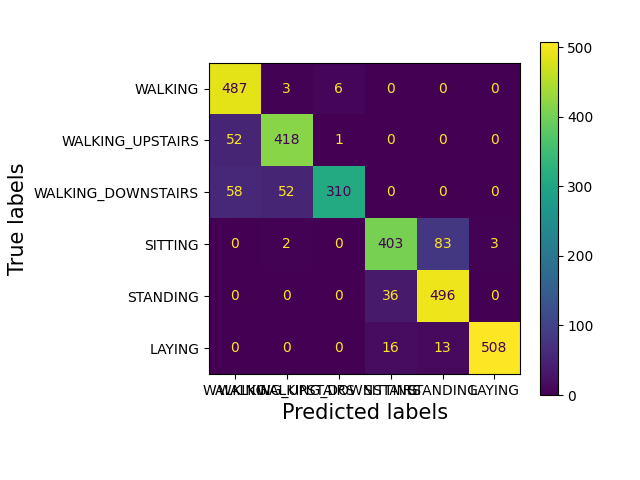

Далее, я проделала те же самые шаги, изменив параметр metric на manhattan: обучила модель (объект класса KNeighborsClassification) с заданными гиперпараметрами metric = 'manhattan' и algorithm = 'brute', и попробуем подобрать оптимальное число соседей. Результат построения графиков:
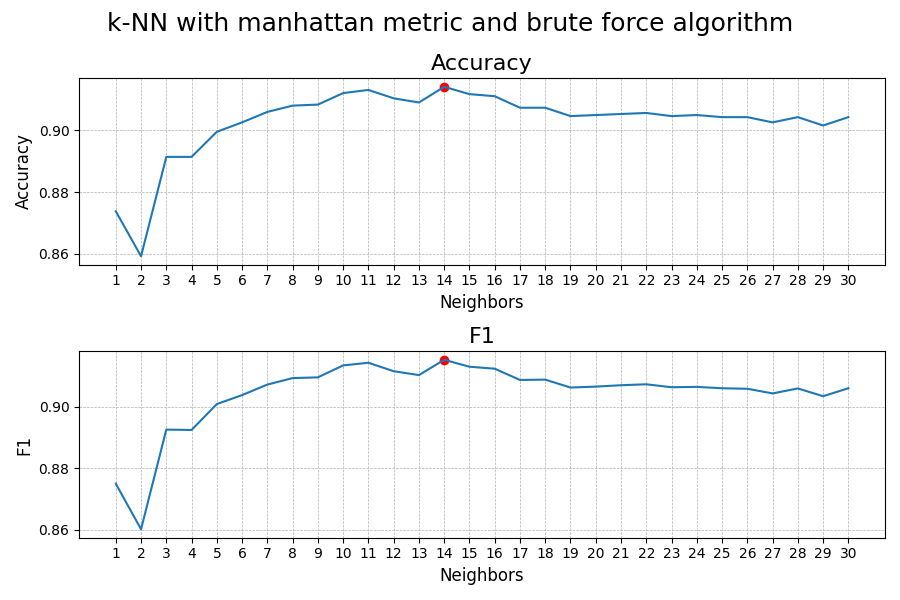

Мы можем видеть, что оценки по метрикам F1 и Асcuracy близки, и их значения максимальны при k = 14. Рассмотрим модель kNN с данными гиперпараметрами (k = 14, metric = manhattan, algorithm = brute):

```
                    precision    recall  f1-score   support

           WALKING       0.85      0.99      0.91       496
  WALKING_UPSTAIRS       0.87      0.90      0.89       471
WALKING_DOWNSTAIRS       0.98      0.75      0.85       420
           SITTING       0.95      0.85      0.90       491
          STANDING       0.88      0.97      0.92       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.91      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.91      0.91      2947
```
Confusion matrix:

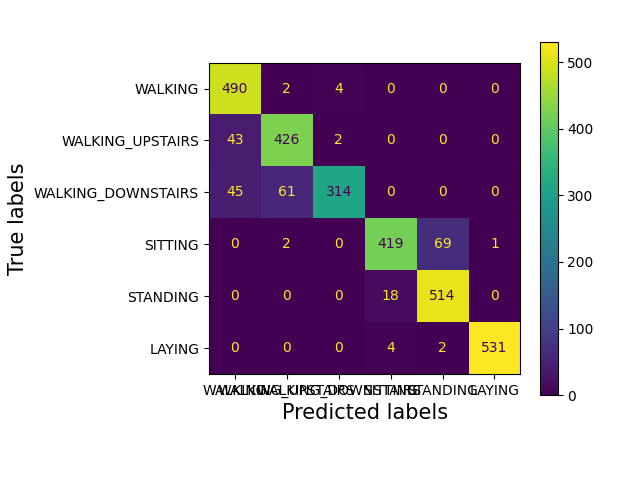

Теперь я проделала те же самые шаги, изменив параметр metric на chebyshev: обучила модель (объект класса KNeighborsClassification) с заданными гиперпараметрами metric = 'chebyshev' и algorithm = 'brute', и попробуем подобрать оптимальное число соседей. Результат построения графиков:
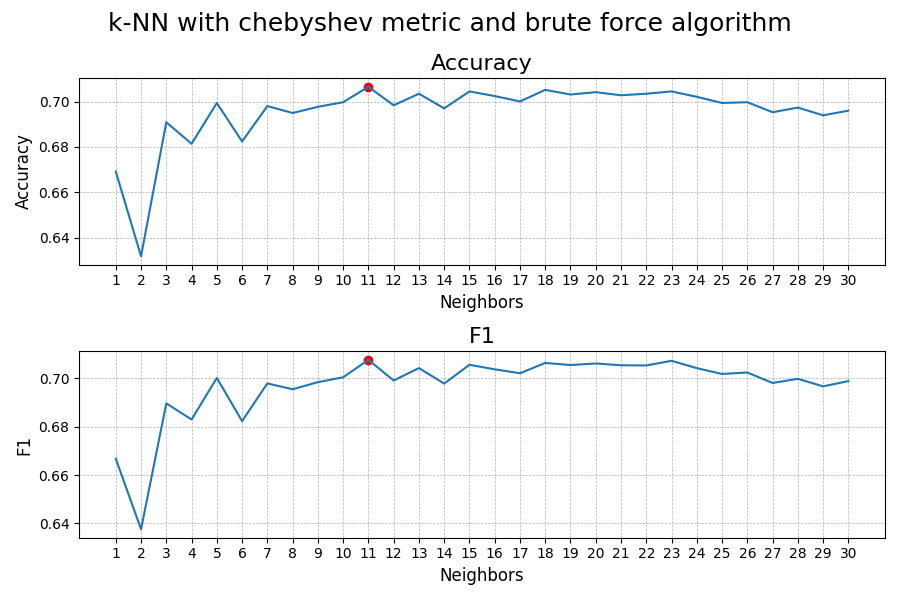

Мы можем видеть, что оценки по метрикам F1 и Асcuracy близки, и их значения максимальны при k = 11. Рассмотрим модель kNN с данными гиперпараметрами (k = 11, metric = chebyshev, algorithm = brute):

```
                    precision    recall  f1-score   support

           WALKING       0.53      0.84      0.65       496
  WALKING_UPSTAIRS       0.74      0.66      0.70       471
WALKING_DOWNSTAIRS       0.78      0.40      0.53       420
           SITTING       0.68      0.63      0.65       491
          STANDING       0.69      0.77      0.73       532
            LAYING       0.99      0.85      0.92       537

          accuracy                           0.71      2947
         macro avg       0.73      0.70      0.70      2947
      weighted avg       0.74      0.71      0.71      2947
```
Confusion matrix:

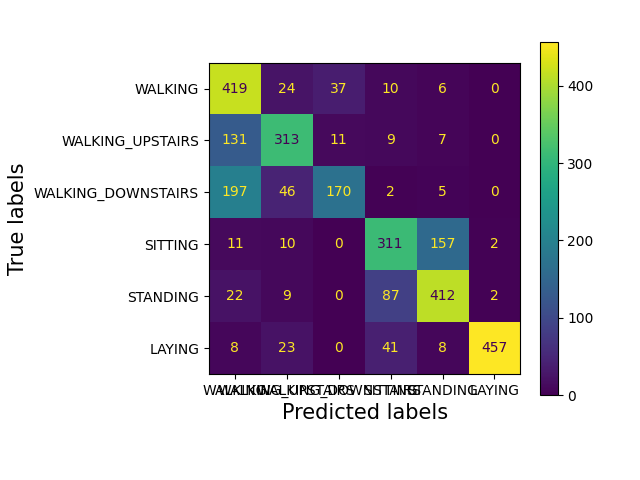

Таким образом, мы проанализировали все возможные комбинации зачений гиперпараметров k и metric для модели kNN с заданным гиперпараметром algorithm = brute. Самым эффективным из них оказался алгоритм со значениями k = 14, metric = manhattan.

Далее я изменила параметр algorithm на kd_tree. Как и ожидалось, результаты вычислений оказались идентичными тем, что были получены при algorithm = brute.

Эвклидова метрика:

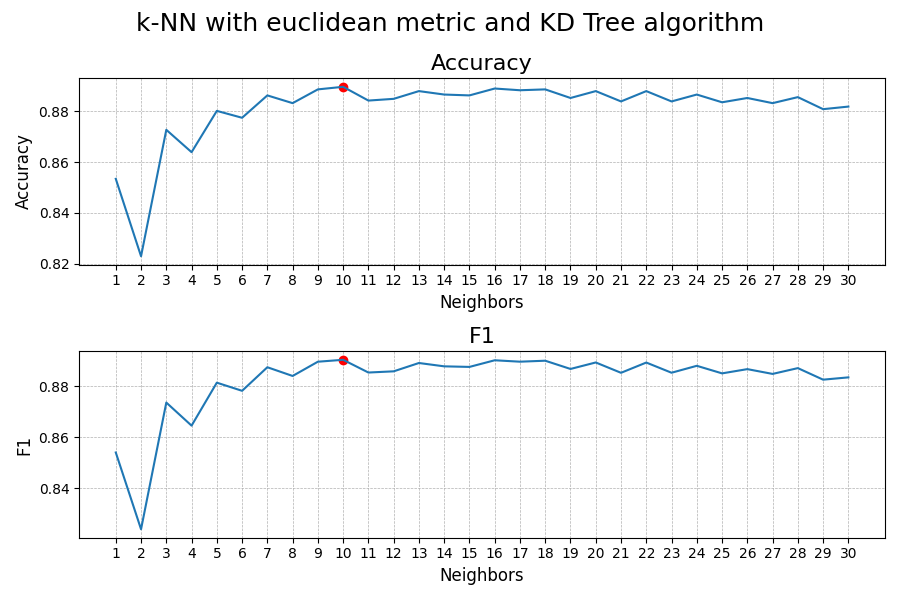



Classification report и confusion matrix при k = 10:

```
                    precision    recall  f1-score   support

           WALKING       0.82      0.98      0.89       496
  WALKING_UPSTAIRS       0.88      0.89      0.88       471
WALKING_DOWNSTAIRS       0.98      0.74      0.84       420
           SITTING       0.89      0.82      0.85       491
          STANDING       0.84      0.93      0.88       532
            LAYING       0.99      0.95      0.97       537

          accuracy                           0.89      2947
         macro avg       0.90      0.88      0.89      2947
      weighted avg       0.90      0.89      0.89      2947
```

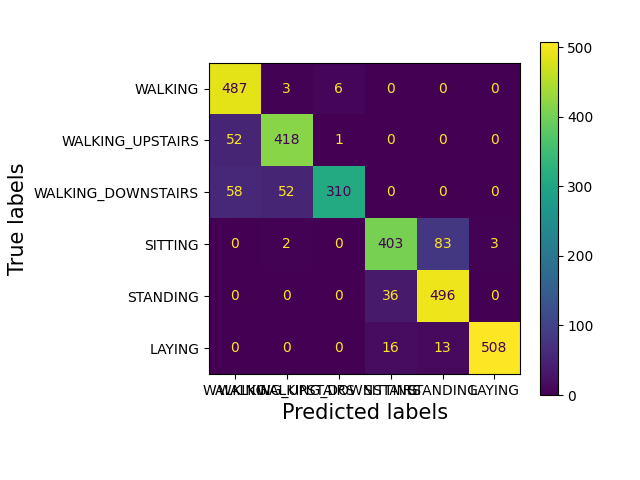

Махэттенская метрика:
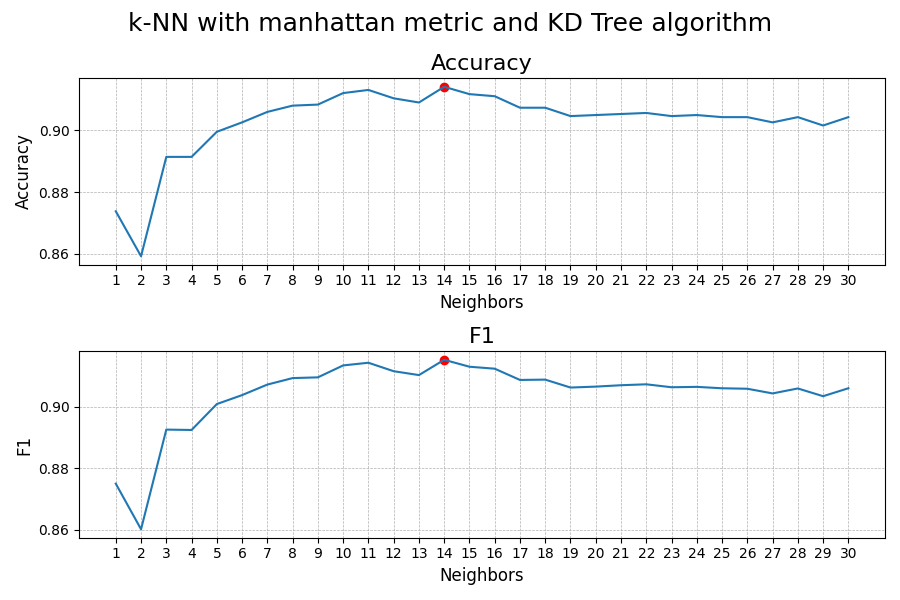

Classification report и confusion matrix при k = 14:

```
                    precision    recall  f1-score   support

           WALKING       0.85      0.99      0.91       496
  WALKING_UPSTAIRS       0.87      0.90      0.89       471
WALKING_DOWNSTAIRS       0.98      0.75      0.85       420
           SITTING       0.95      0.85      0.90       491
          STANDING       0.88      0.97      0.92       532
            LAYING       1.00      0.99      0.99       537

          accuracy                           0.91      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.91      0.91      2947
```
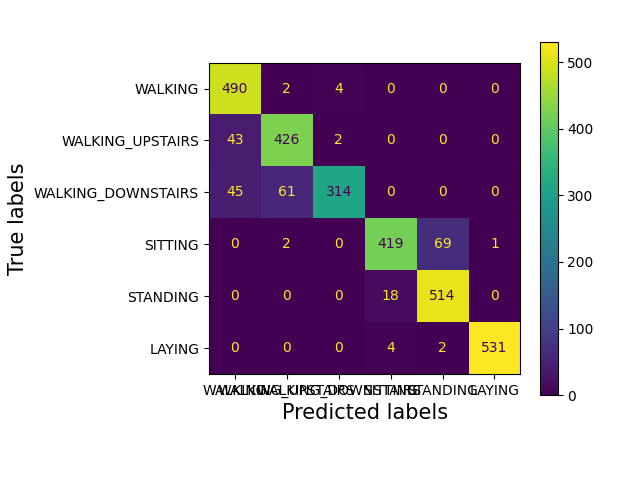

Метрика Чебышева:
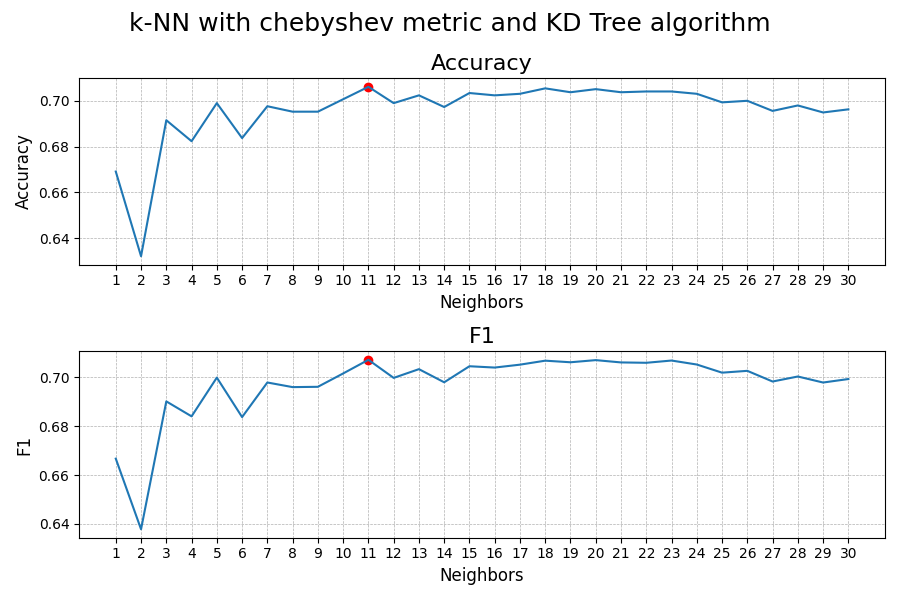

Classification report и confusion matrix при k = 11:

```
                    precision    recall  f1-score   support

           WALKING       0.53      0.84      0.65       496
  WALKING_UPSTAIRS       0.74      0.66      0.70       471
WALKING_DOWNSTAIRS       0.78      0.40      0.53       420
           SITTING       0.68      0.63      0.65       491
          STANDING       0.69      0.77      0.73       532
            LAYING       0.99      0.85      0.92       537

          accuracy                           0.71      2947
         macro avg       0.73      0.70      0.70      2947
      weighted avg       0.74      0.71      0.71      2947
```

Таким образом, можно сделать вывод, что самым эффективным из использованных методов оказалась модель с гиперпараметрами k = 14, metric = manhattan. В данном случае F1 weighted = 0.91, accuraccy = 0.91, weighted precision = 0.92, weighted recall = 0.91.

Далее, я применила GridSearch для автоматического подбора гиперпараметров metric, n_neighbors и weights. Полный код реализации GridSearch:

In [ ]:
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

def read_data(filename):
    return pd.read_csv(filename)

df = read_data("/content/sample_data/test.csv")

label_dict = {'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':2, 'SITTING':3, 'STANDING':4, 'LAYING':5}

def load_dataset(label_dict):
    train_x = read_data("/content/sample_data/test.csv").values[:, :-2]
    train_y = read_data("/content/sample_data/test.csv")['Activity']
    train_y = train_y.map(label_dict).values

    test_x = read_data("/content/sample_data/test.csv").values[:, :-2]
    test_y = read_data("/content/sample_data/test.csv")['Activity']
    test_y = test_y.map(label_dict).values
    return(train_x, train_y, test_x, test_y)

train_x, train_y, test_x, test_y = load_dataset(label_dict)

#масштбирование данных
scaler = StandardScaler()
scaler.fit(train_x)
train_x_scaled = scaler.transform(train_x)
test_x_scaled = scaler.transform(test_x)

def grid_search(train_x_scaled, train_y, test_x_scaled, test_y, label_dict):
    #определение сетки параметров
    param_grid = {
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'n_neighbors': np.arange(1, 31),
        "weights": ["uniform", "distance"],
    }

    # Создание объекта KNeighborsClassifier
    knn = KNeighborsClassifier()

    # Определение функции оценки (метрики)
    scorer = make_scorer(f1_score, average='weighted')

    # Создание объекта GridSearchCV
    grid_search = GridSearchCV(knn, param_grid, scoring=scorer, cv=5)

    # Обучение модели с использованием GridSearchCV
    grid_search.fit(train_x_scaled, train_y)

    # Вывод лучших параметров и оценки
    print("Лучшие параметры:", grid_search.best_params_)
    print("Metric:", grid_search.best_params_["metric"])
    print("Num neighbors:", grid_search.best_params_["n_neighbors"])
    print("Weigths:", grid_search.best_params_["weights"])
    print("Лучшая оценка F1 (weighted):", grid_search.best_score_)

    # Оценка на тестовом наборе с лучшими параметрами
    best_knn = grid_search.best_estimator_
    y_pred = best_knn.predict(test_x_scaled)
    test_f1 = f1_score(test_y, y_pred, average='weighted')
    print(f"F1-мера на тестовом наборе (weighted): {test_f1}")


grid_search(train_x_scaled, train_y, test_x_scaled, test_y, label_dict)

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Metric: manhattan
Num neighbors: 14
Weigths: distance
Лучшая оценка F1 (weighted): 0.9017532833223584
F1-мера на тестовом наборе (weighted): 1.0


Результаты:

Лучшие параметры: {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Metric: manhattan
Num neighbors: 14
Weigths: distance
Лучшая оценка F1 (weighted) на train: 0.9017532833223584
F1-мера на тестовом наборе (weighted): 1.0

Как можно заметить, результаты при поиске оптимальных гиперпараметров при помощи GridSearch и при поиске "вручную" совпали.

### Классификация методом опорных векторов (SVM).


На данном этапе я выполнила классификацию, используя алгоритмы One-vs-One и One-vs-Rest. Для каждого из алгоритмов я попробовала указать разные значения для гиперпараметра SVC kernel, а именно linear, rbf (radial basis kernel) и poly.

Реализация алгоритма One vs One со значением kernel = linear:


In [ ]:
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

#загрузка данных
def read_data(filename):
    return pd.read_csv(filename)

df = read_data("/content/sample_data/test.csv")

label_dict = {'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':2, 'SITTING':3, 'STANDING':4, 'LAYING':5}

def load_dataset(label_dict):
    train_x = read_data("/content/sample_data/test.csv").values[:, :-2]
    train_y = read_data("/content/sample_data/test.csv")['Activity']
    train_y = train_y.map(label_dict).values

    test_x = read_data("/content/sample_data/test.csv").values[:, :-2]
    test_y = read_data("/content/sample_data/test.csv")['Activity']
    test_y = test_y.map(label_dict).values
    return(train_x, train_y, test_x, test_y)

train_x, train_y, test_x, test_y = load_dataset(label_dict)

#масштбирование данных
scaler = StandardScaler()
scaler.fit(train_x)
train_x_scaled = scaler.transform(train_x)
test_x_scaled = scaler.transform(test_x)

#создание и обучение модели
def one_vs_one_svm(train_x_scaled, test_x_scaled, train_y, test_y):
    ovo_svm = OneVsOneClassifier(SVC(kernel='linear'))
    ovo_svm.fit(train_x_scaled, train_y)
    ovo_y_pred = ovo_svm.predict(test_x_scaled)

    print("\nOne-vs-One:")
    print("Accuracy:", accuracy_score(test_y, ovo_y_pred))
    print("F1 (weighted):", f1_score(test_y, ovo_y_pred, average='weighted'))
    print(classification_report(test_y, ovo_y_pred))

one_vs_one_svm(train_x_scaled, test_x_scaled, train_y, test_y)

Результаты:

```
One-vs-One, linear:
Accuracy: 0.9616559212758737
F1 (weighted): 0.9615296110604982
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       496
           1       0.96      0.97      0.97       471
           2       0.99      0.95      0.97       420
           3       0.96      0.88      0.92       491
           4       0.90      0.97      0.93       532
           5       1.00      1.00      1.00       537

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947
```

Визуализируем результаты и построим confusion matrix:


In [ ]:
metrics.ConfusionMatrixDisplay(confusion_matrix=metrics.confusion_matrix(test_y, ovo_y_pred), display_labels=label_dict).plot()
plt.tight_layout(pad=3)
label_font = {"size": "15"}
plt.xlabel("Predicted labels", fontdict=label_font)
plt.ylabel("True labels", fontdict=label_font)
plt.show()

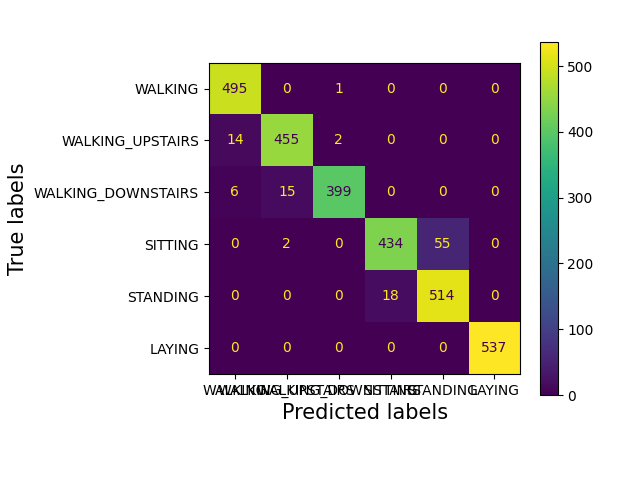

Далее я проделала аналогичные действия, изменив гиперпараметр kernel на rbf. Результаты вычислений:

```
One-vs-One, rbf:
Accuracy: 0.9548693586698337
F1 (weighted): 0.9547739948036994
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       496
           1       0.93      0.97      0.95       471
           2       0.98      0.91      0.95       420
           3       0.94      0.91      0.93       491
           4       0.92      0.95      0.94       532
           5       1.00      1.00      1.00       537

    accuracy                           0.95      2947
   macro avg       0.96      0.95      0.95      2947
weighted avg       0.96      0.95      0.95      2947
```

Confusion matrix:

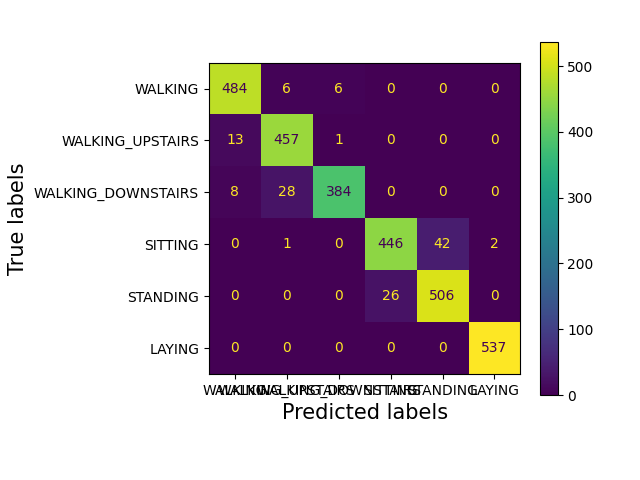

Далее я проделала аналогичные действия, изменив гиперпараметр kernel на poly. Результаты вычислений:

```
One-vs-One, poly:
Accuracy: 0.9287410926365796
F1 (weighted): 0.9276501506449039
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       496
           1       0.88      0.94      0.91       471
           2       0.98      0.76      0.86       420
           3       0.96      0.89      0.93       491
           4       0.91      0.96      0.93       532
           5       1.00      0.99      1.00       537

    accuracy                           0.93      2947
   macro avg       0.93      0.92      0.92      2947
weighted avg       0.93      0.93      0.93      2947
```
Confusion matrix:

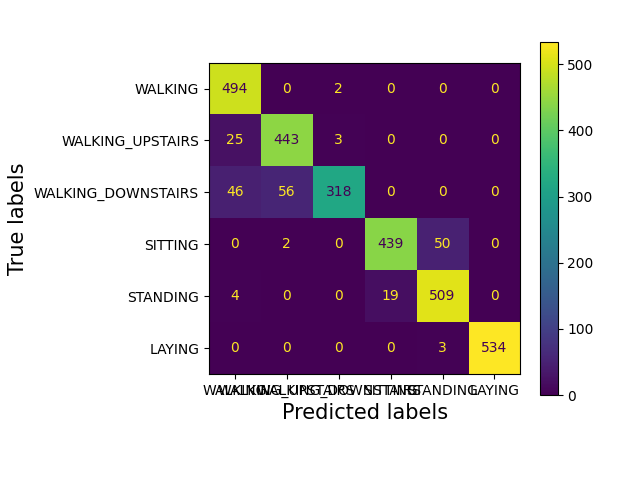

Таким образом, самым эффективным алгоритмом One vs One оказался алгоритм с гиперпараметром kernel = linear. Это может быть объяснимо тем, что данные близки к линейной разделимости в изначальном признаковом пространстве (возможно построить разделяющую гиперплоскость).

Далее я реализовала алгоритм One vs Rest. Сначала - с гиперпараметром kernel = linear:



In [ ]:
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

#загрузка данных
def read_data(filename):
    return pd.read_csv(filename)

df = read_data("/content/sample_data/test.csv")

label_dict = {'WALKING':0, 'WALKING_UPSTAIRS':1, 'WALKING_DOWNSTAIRS':2, 'SITTING':3, 'STANDING':4, 'LAYING':5}

def load_dataset(label_dict):
    train_x = read_data("/content/sample_data/test.csv").values[:, :-2]
    train_y = read_data("/content/sample_data/test.csv")['Activity']
    train_y = train_y.map(label_dict).values

    test_x = read_data("/content/sample_data/test.csv").values[:, :-2]
    test_y = read_data("/content/sample_data/test.csv")['Activity']
    test_y = test_y.map(label_dict).values
    return(train_x, train_y, test_x, test_y)

train_x, train_y, test_x, test_y = load_dataset(label_dict)

#масштбирование данных
scaler = StandardScaler()
scaler.fit(train_x)
train_x_scaled = scaler.transform(train_x)
test_x_scaled = scaler.transform(test_x)

#создание и обучение модели
def one_vs_rest_svm(train_x_scaled, test_x_scaled, train_y, test_y, label_dict):
    ovr_svm = OneVsRestClassifier(SVC(kernel='linear'))
    ovr_svm.fit(train_x_scaled, train_y)
    ovr_y_pred = ovr_svm.predict(test_x_scaled)

    #построение и визуализация confusion matrix
    metrics.ConfusionMatrixDisplay(confusion_matrix=metrics.confusion_matrix(test_y, ovr_y_pred),
                                   display_labels=label_dict).plot()
    plt.tight_layout(pad=3)
    label_font = {"size": "15"}
    plt.xlabel("Predicted labels", fontdict=label_font)
    plt.ylabel("True labels", fontdict=label_font)
    plt.show()
    # оценка результатов
    print("One-vs-Rest:")
    print("Accuracy:", accuracy_score(test_y, ovr_y_pred))
    print("F1 (weighted):", f1_score(test_y, ovr_y_pred, average='weighted'))
    print(classification_report(test_y, ovr_y_pred))

one_vs_one_svm(train_x_scaled, test_x_scaled, train_y, test_y)

Результаты:

```
One-vs-Rest, linear:
Accuracy: 0.9616559212758737
F1 (weighted): 0.9613600734352313
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       496
           1       0.98      0.96      0.97       471
           2       1.00      0.97      0.98       420
           3       0.97      0.86      0.91       491
           4       0.90      0.98      0.94       532
           5       0.98      1.00      0.99       537

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947
```

Визуализация confusion matrix:

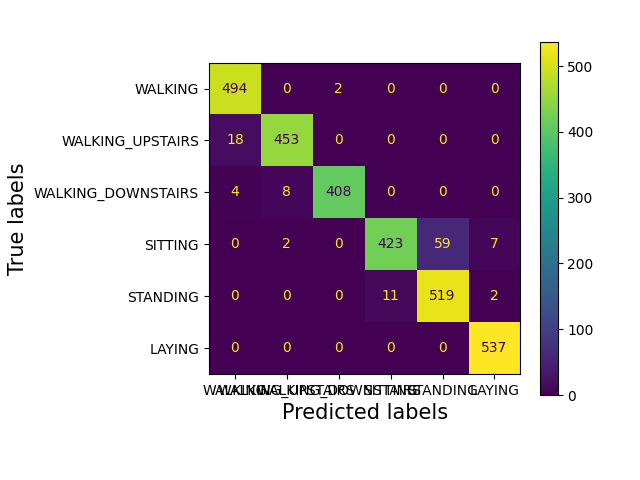

Далее я проделала аналогичные вычисления, заменив гиперпараметр kernel на rbf.

Результаты:

```
One-vs-Rest, rbf:
Accuracy: 0.9514760773668137
F1 (weighted): 0.9514064701101823
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       496
           1       0.93      0.97      0.95       471
           2       0.98      0.92      0.95       420
           3       0.94      0.89      0.92       491
           4       0.91      0.95      0.93       532
           5       0.99      0.99      0.99       537

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947
```
Confusion matrix:

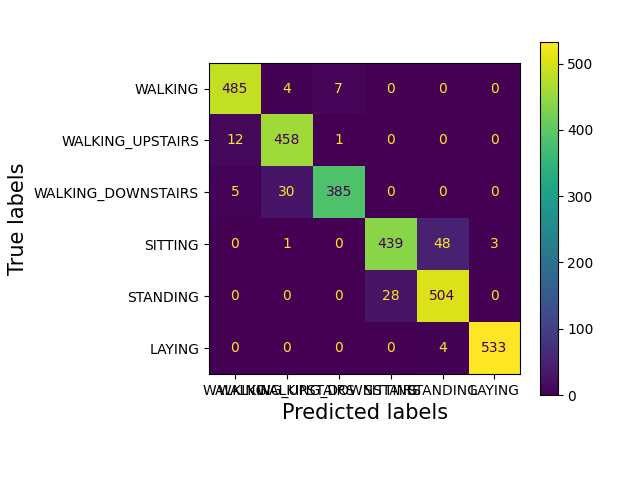


Далее я проделала аналогичные вычисления, заменив гиперпараметр kernel на poly.

Результаты:
```
One-vs-Rest, poly:
Accuracy: 0.9341703427214116
F1 (weighted): 0.9338013054158999
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       496
           1       0.89      0.96      0.92       471
           2       0.99      0.83      0.90       420
           3       0.94      0.87      0.91       491
           4       0.88      0.95      0.91       532
           5       1.00      0.98      0.99       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947
```

Confusion matrix:

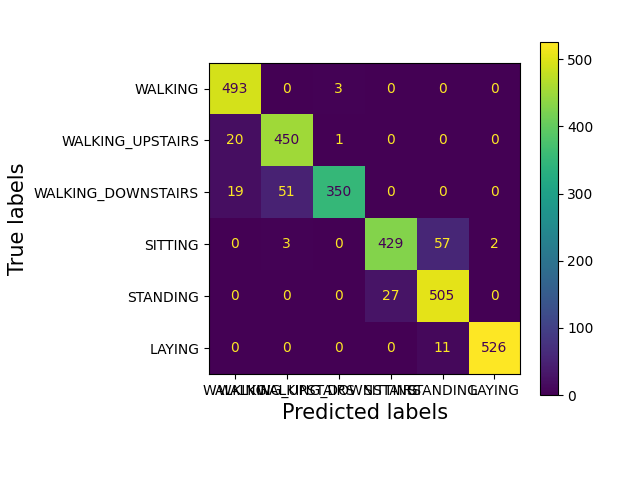


Таким образом, как и при реализации One vs One, алгоритм One vs Rest показал наилучшие результаты при использовании линейной функции ядра.


## Сравнение результатов и выводы

Сравним наилучшие результаты работы рассмотренных моделей по метрике F1 (weighted):

```

МОДЕЛЬ                  ГИПЕРПАРАМЕТРЫ                 F1 WEIGHTED

kNN                         k = 14                          0.91
                      metric = manhattan
                      algorithm = brute       


SVM OvO                kernel = linear               0.9615296110604982


SVM OvR                kernel = linear               0.9613600734352313
```
Таким образом, в результате оценок моделей по F1 (weighted) самыми эффективными оказались алгоритмы SVM One vs One и One vs Rest (One vs One "побеждает" с небольшим отрывом примерно в 0.00017 от One to Rest). Наименее эффективным оказался алгоритм k Nearest Neighbors, хотя и он показал достаточно неплохой результат.
